In [2]:
# step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# step 2: load dataset
data=pd.read_csv("amazon_laptop_price_dataset.csv")

In [4]:
#covert Price_USD to Price_Rupess
data['Price_Rupess']=data['Price_USD']*90.94


In [5]:
data.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_USD,Price_Rupess
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,1092.04,99310.1176
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,1934.84,175954.3496
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,758.86,69010.7284
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,1430.88,130124.2272
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,1457.77,132569.6038


In [6]:
#drop the price_usd column
data.drop('Price_USD',axis=1,inplace=True)

In [7]:
data.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_Rupess
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,99310.1176
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,175954.3496
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,69010.7284
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,130124.2272
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,132569.6038


In [8]:
# step 3: Data Preprocessing
data.isnull().sum()

Brand               0
Processor           0
RAM_GB              0
Storage_GB          0
Operating_System    0
GPU                 0
Rating              0
Price_Rupess        0
dtype: int64

In [9]:
# check statistics of the dataset
data.describe()

,RAM_GB,Storage_GB,Rating,Price_Rupess
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,15.252000,460.032000,4.030300,132972.222462
std,10.693683,336.083691,0.580852,43623.691973
min,4.000000,128.000000,3.000000,36815.240200
25%,8.000000,128.000000,3.500000,100175.184350
50%,16.000000,256.000000,4.100000,129289.852700
75%,32.000000,512.000000,4.500000,163090.204550
max,32.000000,1024.000000,5.000000,263439.539000


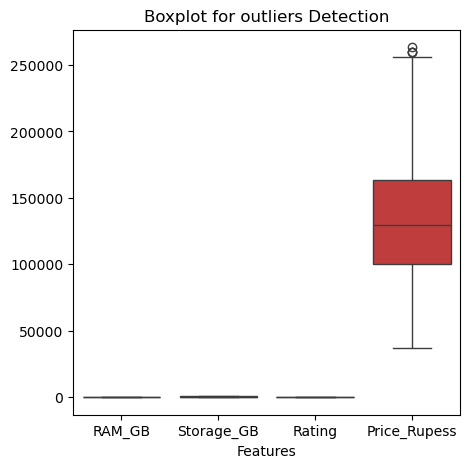

In [10]:
# check the outliers in the dataset
plt.figure(figsize=(5,5))
sns.boxplot(data=data)
plt.title("Boxplot for outliers Detection")
plt.xlabel("Features")
plt.show()

In [11]:
# find the outliers in the data set
Q1=data['Price_Rupess'].quantile(0.25)
Q3=data['Price_Rupess'].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

outliers=data[(data['Price_Rupess']<lower_bound) | (data['Price_Rupess']>upper_bound)]
print("outliers in price colums")
outliers

outliers in price colums


,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_Rupess
101,Apple,Intel i7,16,1024,macOS,NVIDIA RTX 3050,4.1,260055.6616
598,Apple,Intel i7,32,1024,macOS,Integrated,4.5,263439.5390
617,Apple,AMD Ryzen 7,32,1024,macOS,Integrated,5.0,260105.6786
865,HP,Intel i7,32,1024,macOS,NVIDIA RTX 3050,3.1,259960.1746


In [12]:
# remove the outliers from the dataset
data=data[(data['Price_Rupess']>=lower_bound) & (data['Price_Rupess']<=upper_bound)]

In [13]:
#check gpu column value count
print(data['GPU'].value_counts())

GPU
Integrated         277
AMD Radeon         268
NVIDIA RTX 3050    244
NVIDIA GTX 1650    207
Name: count, dtype: int64


In [14]:
data.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_Rupess
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,99310.1176
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,175954.3496
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,69010.7284
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,130124.2272
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,132569.6038


In [15]:
data['Operating_System'] = data['Operating_System'].replace(['Windows 11','Windows 10'],'Windows')
data['Operating_System'].value_counts()

Operating_System
Windows    671
macOS      325
Name: count, dtype: int64

In [16]:
data['Processor'] = data['Processor'].map({'Intel i3': 1, 'Intel i5': 2, 'Intel i7': 3, 'AMD Ryzen 3': 1, 'AMD Ryzen 5': 2, 'AMD Ryzen 7': 3})
data['Processor'].value_counts()

Processor
2    349
3    339
1    308
Name: count, dtype: int64

In [17]:
data['GPU']=data['GPU'].map({'Integrated':0,'AMD Radeon':1,'NVIDIA GTX 1650':2,'NVIDIA RTX 3050':3})
data['GPU'].value_counts()

GPU
0    277
1    268
3    244
2    207
Name: count, dtype: int64

In [18]:
data.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_Rupess
0,MSI,1,4,512,macOS,1,4.2,99310.1176
1,Lenovo,3,32,128,macOS,2,3.1,175954.3496
2,Asus,3,8,256,Windows,0,3.6,69010.7284
3,Dell,3,16,512,Windows,1,3.6,130124.2272
4,MSI,3,8,512,Windows,3,3.8,132569.6038


In [19]:
# brand column encoding using one hot encoding 
from sklearn.preprocessing import OneHotEncoder

# load the one hot encoder

encoder=OneHotEncoder(sparse_output=False) 

brand_encoded=encoder.fit_transform(data[['Brand']])

brand_encoded 


array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(996, 7))

In [20]:
#  brand_encoded add in the dataframe
brand_encoded_df=pd.DataFrame(brand_encoded,columns=encoder.get_feature_names_out(['Brand']))
data=pd.concat([data,brand_encoded_df],axis=1)
data.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_Rupess,Brand_Acer,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI
0,MSI,1.0,4.0,512.0,macOS,1.0,4.2,99310.1176,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Lenovo,3.0,32.0,128.0,macOS,2.0,3.1,175954.3496,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Asus,3.0,8.0,256.0,Windows,0.0,3.6,69010.7284,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,Dell,3.0,16.0,512.0,Windows,1.0,3.6,130124.2272,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,MSI,3.0,8.0,512.0,Windows,3.0,3.8,132569.6038,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [25]:
# all brand column convert into int 


cols = ['Brand_Acer','Brand_Apple','Brand_Asus','Brand_Dell','Brand_HP','Brand_Lenovo','Brand_MSI']

data[cols] = data[cols].fillna(0).astype(int)

data.head()

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_Rupess,Brand_Acer,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI
0,MSI,1.0,4.0,512.0,macOS,1.0,4.2,99310.1176,0,0,0,0,0,0,1
1,Lenovo,3.0,32.0,128.0,macOS,2.0,3.1,175954.3496,0,0,0,0,0,1,0
2,Asus,3.0,8.0,256.0,Windows,0.0,3.6,69010.7284,0,0,1,0,0,0,0
3,Dell,3.0,16.0,512.0,Windows,1.0,3.6,130124.2272,0,0,0,1,0,0,0
4,MSI,3.0,8.0,512.0,Windows,3.0,3.8,132569.6038,0,0,0,0,0,0,1


In [27]:
# Divide data into x and Y
x=data.drop(['Price_Rupess','Brand'],axis=1)
y=data['Price_Rupess']

In [28]:
# split data into train and test
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [29]:
print("X Train:", x_train.shape)
print("X Test :", x_test.shape)
print("Y Train:", y_train.shape)
print("Y Test :", y_test.shape)

X Train: (800, 13)
X Test : (200, 13)
Y Train: (800,)
Y Test : (200,)


In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate X and y
X = data.drop(['Price_Rupess', 'Brand'], axis=1)
y = data['Price_Rupess']

# Combine to remove NaN in target
dataset = pd.concat([X, y], axis=1)
dataset = dataset.dropna(subset=['Price_Rupess'])

X = dataset.drop('Price_Rupess', axis=1)
y = dataset['Price_Rupess']

# Encode categorical
X = pd.get_dummies(X, drop_first=True)

# Handle missing in features
X = X.fillna(X.mean())

# Split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LinearRegression()
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

# Evaluate
print("MAE  :", mean_absolute_error(y_test, y_pred))
print("MSE  :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2   :", r2_score(y_test, y_pred))

MAE  : 11303.176524927092
MSE  : 230831270.5927467
RMSE : 15193.132349609368
R2   : 0.8900418866765332
